<a href="https://colab.research.google.com/github/melissa-04/melisayla-biyoinformatik/blob/main/notebooks/scrna/05_isaretciler.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# İşaretçi genler

Kümeleme bize numaralı gruplar verdi; bu defterde o numaralara kimlik kazandıracak kanıtı topluyoruz. İki araç kullanacağız: her kümenin kendine özgü genlerini sıralayan `rank_genes_groups`, ve bilinen işaretçi genlerin küme başına ifadesini gösteren `dotplot`. Adlandırmanın kendisi sizin göreviniz olacak.

In [1]:
%pip install -q scanpy leidenalg igraph

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 65.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 89.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.8/188.8 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.0/40.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 81.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 65.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 4.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source o

## 1. Başlangıç durumu

Önceki rehberlerin tarifi tek hücrede; kümeleme resolution=0.5 ile yapılıyor (9 küme) — küme sayısı az olduğu için adlandırmaya bu çözünürlükten başlamak daha yönetilebilir.

In [2]:
import warnings; warnings.filterwarnings('ignore')
import urllib.request
import scanpy as sc
import numpy as np
import pandas as pd

urllib.request.urlretrieve('https://zenodo.org/records/22655336/files/pbmc3k_ders.h5ad?download=1', 'pbmc3k_ders.h5ad')
a = sc.read_h5ad('pbmc3k_ders.h5ad')
a.layers['sayim'] = a.X.copy()
sc.pp.normalize_total(a, target_sum=1e4)
sc.pp.log1p(a)
sc.pp.highly_variable_genes(a, flavor='seurat', min_mean=0.0125, max_mean=3, min_disp=0.5)
a.raw = a
a = a[:, a.var.highly_variable].copy()
sc.pp.scale(a, max_value=10)
sc.tl.pca(a, svd_solver='arpack', n_comps=50)
sc.pp.neighbors(a, n_neighbors=15, n_pcs=10)
sc.tl.leiden(a, resolution=0.5, key_added='leiden')
print('küme sayısı:', a.obs.leiden.nunique())

küme sayısı: 9


## 2. Her kümenin kendine özgü genleri

`sc.tl.rank_genes_groups(a, 'leiden', method='wilcoxon')` her kümeyi tek tek ele alır ve o kümedeki hücreleri geri kalan bütün hücrelerle karşılaştırıp genleri sıralar. `method='wilcoxon'` sıralama tabanlı bir testtir: dağılım varsayımı azdır ve tek hücre verisi için alan standardıdır. Önemli bir ayrıntı: bu fonksiyon ifadeleri varsayılan olarak `a.raw`'dan okur — yani 2.3'te sakladığımız tam log-normalize matristen. Daraltılmış 1.860 gen değil, 13.714 genin tamamı yarışır; işaretçi olabilecek hiçbir gen dışarıda kalmaz.

Sonuç `a.uns['rank_genes_groups']` içine yazılır. Aşağıda iki görünüm var: küme başına ilk 5 genin tablosu ve ilk 10 genin grafiği.

       0      1       2         3     4       5     6         7      8
0   LDHB  RPS12  S100A9      CD74  CCL5    LST1  NKG7  HLA-DPB1    PF4
1    LTB   RPS6  S100A8     CD79A  NKG7   COTL1  GZMB  HLA-DPA1  GNG11
2   CD3D  RPL32     LYZ   HLA-DRA  GZMA  FCER1G  PRF1   HLA-DRA   SDPR
3   TPT1  RPL13  TYROBP     CD79B  CST7    AIF1  GNLY  HLA-DRB1   PPBP
4  RPS12   RPS3     FTL  HLA-DPB1   B2M    FTH1  GZMA      CST3   NRGN


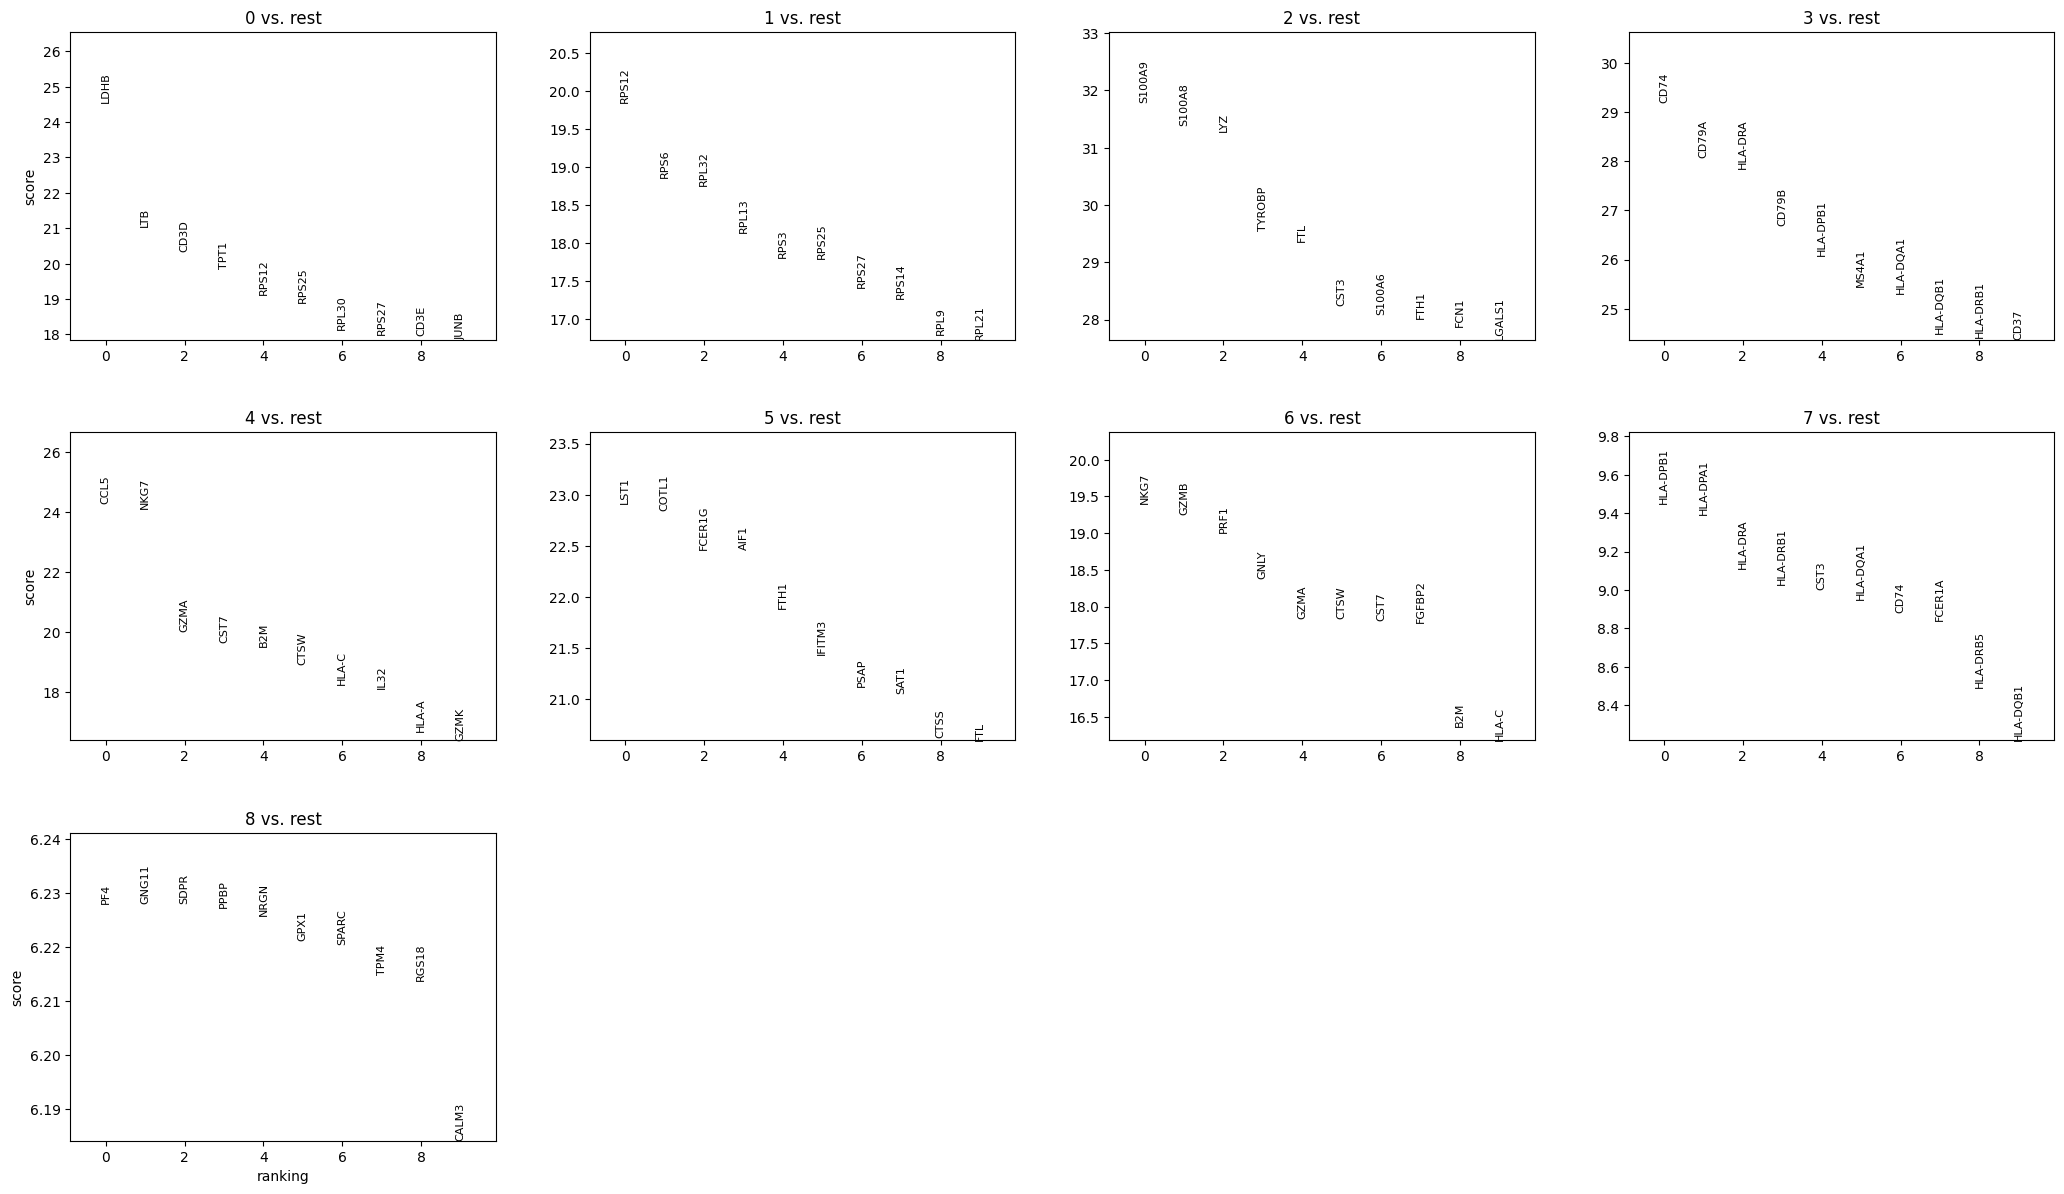

In [3]:
sc.tl.rank_genes_groups(a, 'leiden', method='wilcoxon')

print(pd.DataFrame(a.uns['rank_genes_groups']['names']).head(5).to_string())
sc.pl.rank_genes_groups(a, n_genes=10, sharey=False)

## 3. Bilinen işaretçilerle karşılaştırma

Yukarıdaki tablo veriden çıkan adaylardır; adlandırma için bunları literatürün bilinen işaretçileriyle karşılaştırırız. PBMC için klasik liste şöyle:

- **CD3D, CD3E, IL7R, CCR7** — T hücreleri (IL7R+CCR7 naif CD4'e işaret eder)
- **CD8A** — sitotoksik (CD8+) T
- **MS4A1, CD79A** — B hücreleri
- **LYZ, CD14** — klasik (CD14+) monositler
- **FCGR3A, MS4A7** — FCGR3A+ (CD16+) monositler
- **NKG7, GNLY** — NK hücreleri
- **FCER1A, CST3** — dendritik hücreler
- **PPBP** — trombositler

`sc.pl.dotplot(a, panel, groupby='leiden')` bu genlerin küme başına ifadesini tek resimde gösterir: her noktanın boyu, o kümede geni ifade eden hücre yüzdesi; rengi, ortalama ifade düzeyi. Bir kümenin kimliği, hangi işaretçi sütunlarında hem büyük hem koyu nokta verdiğine bakılarak okunur.

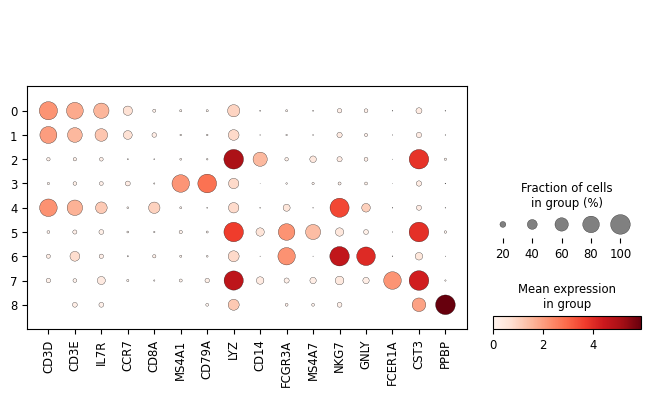

In [4]:
panel = ['CD3D', 'CD3E', 'IL7R', 'CCR7', 'CD8A', 'MS4A1', 'CD79A',
         'LYZ', 'CD14', 'FCGR3A', 'MS4A7', 'NKG7', 'GNLY', 'FCER1A', 'CST3', 'PPBP']
sc.pl.dotplot(a, panel, groupby='leiden')

## Kendin dene

Üç görev. Birincisi: ilk-5 tablosunu ve dotplot'u birlikte kullanarak dokuz kümenin her birine bir hücre tipi adı önerin — dokuz satırlık bir eşleme tablosu yazın; emin olamadıklarınıza soru işareti koymak meşrudur, kesin bilmiyormuş gibi yapmaktan iyidir. İkincisi: en küçük iki kümenin kimliği ne çıktı? Önceki rehberde "13 hücrelik grup gerçek mi, gürültü mü" sorusuna verdiğiniz cevapla tek cümlede yüzleştirin. Üçüncüsü: koştuğunuz defteri indirip eşleme tablonuzla birlikte gönderin; bu rehberin yazısı sizin tablonuzla yazılacak ve bir sonraki rehberde adlar haritaya işlenecek.